# YOLOv8n + Fast NMS — Real-Time Object Detection on KITTI

This notebook evaluates **YOLOv8n** fine-tuned on the KITTI dataset and benchmarks  
the effect of replacing standard NMS with **Fast NMS** (vectorised GPU IoU matrix).

| Section | Content |
|---------|---------------------------|
| 0 | Colab environment setup |
| 1 | Dataset verification |
| 2 | YOLOv8n training (optional) |
| 3 | mAP evaluation |
| 4 | Fast NMS benchmark |
| 5 | Demo — 5 sample images |
| 6 | Results summary |

---
## 0. Setup
Run all cells in this section once at the start of every Colab session.

In [1]:
# 0-A: GPU check
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('⚠  No GPU — Runtime → Change runtime type → T4 GPU')

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# 0-B: Mount Google Drive (caches model weights between sessions)
from google.colab import drive
drive.mount('/content/drive')

import os
# Cache Ultralytics weights so re-runs don't re-download
os.environ['YOLO_CONFIG_DIR'] = '/content/drive/MyDrive/yolo_cache'

Mounted at /content/drive


In [3]:
# 0-C: Install dependencies
!pip install -q ultralytics
!pip install -q numpy matplotlib pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.7 MB/s eta 0:00:00


In [4]:
# 0-D: Clone / update repo
import os, sys

REPO   = 'Introduction-to-Artificial-Intelligence-Final-Project'
BRANCH = 'claude/musing-brahmagupta-7d497e'

if not os.path.exists(f'/content/{REPO}'):
    !git clone https://github.com/Appledog3572/{REPO}.git /content/{REPO}

%cd /content/{REPO}
!git checkout {BRANCH} -q
!git pull -q

sys.path.insert(0, f'/content/{REPO}')
print('Repo ready.')

Cloning into '/content/Introduction-to-Artificial-Intelligence-Final-Project'...
remote: Enumerating objects: 15111, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 15111 (delta 47), reused 54 (delta 23), pack-reused 15023 (from 2)
Receiving objects: 100% (15111/15111), 446.59 MiB | 40.68 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Updating files: 100% (14999/14999), done.
/content/Introduction-to-Artificial-Intelligence-Final-Project
Repo ready.


---
## 1. Dataset Verification
Expects the KITTI dataset at `datasets/kitti_dataset/`.

In [5]:
from pathlib import Path

DATASET_ROOT = Path('datasets/kitti_dataset')
KITTI_YAML   = 'dataset_configs/kitti.yaml'

for split in ('train', 'val'):
    imgs   = list((DATASET_ROOT / 'images'  / split).glob('*.png'))
    labels = list((DATASET_ROOT / 'labels'  / split).glob('*.txt'))
    print(f'  {split:5s}: {len(imgs):5d} images, {len(labels):5d} labels')

print(f'\nUsing config: {KITTI_YAML}')
assert Path(KITTI_YAML).exists(), 'kitti.yaml not found!'
print('Dataset OK ✓')

  train:  5985 images,  5985 labels
  val  :  1496 images,  1496 labels

Using config: dataset_configs/kitti.yaml
Dataset OK ✓


---
## 2. YOLOv8n Training  *(optional — skip if weights already exist)*

Pre-trained weights are stored in `runs/detect/train-4/weights/best.pt`.  
Run this section only when training from scratch.

In [6]:
# ── Optional: copy saved weights from Drive ──────────────────────────────────
import shutil
DRIVE_WEIGHTS = '/content/drive/MyDrive/yolo_results/yolov8n_kitti/best.pt'
LOCAL_WEIGHTS = 'runs/detect/train-4/weights/best.pt'

if Path(DRIVE_WEIGHTS).exists() and not Path(LOCAL_WEIGHTS).exists():
    Path(LOCAL_WEIGHTS).parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(DRIVE_WEIGHTS, LOCAL_WEIGHTS)
    print(f'Weights restored from Drive → {LOCAL_WEIGHTS}')
elif Path(LOCAL_WEIGHTS).exists():
    print(f'Weights already at {LOCAL_WEIGHTS}')
else:
    print('No saved weights found — run the training cell below.')

Weights already at runs/detect/train-4/weights/best.pt


In [ ]:
# ── Training (skip if best.pt already exists) ─────────────────────────────────
from ultralytics import YOLO

if not Path('runs/detect/train-4/weights/best.pt').exists():
    model = YOLO('yolov8n.pt')
    model.train(
        data=KITTI_YAML,
        epochs=100,
        imgsz=640,
        batch=32,
        device=0,
        optimizer='AdamW',
        lr0=0.001,
    )
    print('Training complete.')

    # Save to Drive for future sessions
    Path('/content/drive/MyDrive/yolo_results/yolov8n_kitti').mkdir(parents=True, exist_ok=True)
    shutil.copy('runs/detect/train/weights/best.pt', DRIVE_WEIGHTS)
    print(f'Weights saved to Drive: {DRIVE_WEIGHTS}')
else:
    print('best.pt found — skipping training.')

---
## 3. mAP Evaluation
Evaluates the fine-tuned YOLOv8n on the KITTI validation split.

In [7]:
from ultralytics import YOLO

BEST_PT = 'runs/detect/train-4/weights/best.pt'
model = YOLO(BEST_PT)
print(f'Model loaded: {BEST_PT}')
print(f'Parameters  : {sum(p.numel() for p in model.model.parameters()):,}')

WARNING ⚠️ user config directory '/content/drive/MyDrive/yolo_cache/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded: runs/detect/train-4/weights/best.pt
Parameters  : 3,012,603


In [8]:
val_results = model.val(
    data=KITTI_YAML,
    split='val',
    imgsz=640,
    device=0,
    verbose=True,
)

map50    = val_results.box.map50
map5095  = val_results.box.map
print(f'\nmAP@0.5      : {map50:.4f}')
print(f'mAP@0.5:0.95 : {map5095:.4f}')

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1951.9±687.8 MB/s, size: 55.6 KB)
val: Scanning /content/Introduction-to-Artificial-Intelligence-Final-Project/datasets/kitti_dataset/labels/val... 1496 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1496/1496 2.1Kit/s 0.7s
val: New cache created: /content/Introduction-to-Artificial-Intelligence-Final-Project/datasets/kitti_dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 8.1it/s 11.6s
                   all       1496       8128      0.431      0.262      0.253      0.134
                   Car       1322       5716      0.692      0.767      0.785      0.474
                   Van        419        555      0.322      0.261      0.223      0.124
                 Truck        212   

---
## 4. Fast NMS Benchmark

**Fast NMS** (YOLACT, Liu et al. 2019) replaces the sequential NMS loop with a single  
vectorised GPU matrix operation, giving ~2× speedup on GPU.

Two sub-experiments:
- **4-A** NMS-only timing on synthetic data (8400 boxes — YOLO's worst case)
- **4-B** Full end-to-end FPS comparison on real KITTI images

In [9]:
# 4-A: NMS-only timing — no model loading needed
import fast_nms
fast_nms.time_nms_only(n_boxes=8400, n_runs=1000, device='cuda')


===== NMS-only timing  [8400 boxes, device=cuda] =====
  Standard NMS        : 2.2033 ms  (454 calls/s)
  Fast NMS            : 30.6654 ms  (33 calls/s)
  Speedup: 0.07×


In [10]:
# 4-B: Full inference comparison — Standard NMS vs Fast NMS
import time
import numpy as np
from ultralytics import YOLO

SAMPLE_IMAGE = 'datasets/kitti_dataset/images/val/000013.png'
N_WARMUP = 20
N_RUNS   = 200

results_bench = {}

for label, use_fast in [('Standard NMS', False), ('Fast NMS', True)]:
    if use_fast:
        fast_nms.patch()
    else:
        fast_nms.unpatch()

    m = YOLO(BEST_PT)

    # Warmup
    for _ in range(N_WARMUP):
        m.predict(SAMPLE_IMAGE, verbose=False, device=0)

    # Timed runs
    times = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        m.predict(SAMPLE_IMAGE, verbose=False, device=0)
        times.append((time.perf_counter() - t0) * 1000)

    mean_ms = float(np.mean(times))
    std_ms  = float(np.std(times))
    results_bench[label] = {'mean_ms': mean_ms, 'std_ms': std_ms}
    print(f'  {label:20s}: {mean_ms:.2f} ± {std_ms:.2f} ms  ({1000/mean_ms:.1f} FPS)')

    del m

fast_nms.unpatch()

[fast_nms] restored original torchvision.ops.nms
  Standard NMS        : 10.23 ± 1.03 ms  (97.8 FPS)
[fast_nms] patched into torchvision.ops.nms
  Fast NMS            : 10.48 ± 1.12 ms  (95.4 FPS)
[fast_nms] restored original torchvision.ops.nms


In [11]:
# 4-C: Print comparison table
std_ms  = results_bench['Standard NMS']['mean_ms']
fast_ms = results_bench['Fast NMS']['mean_ms']
speedup = std_ms / fast_ms

print('\n===== Inference Benchmark (YOLOv8n, KITTI val image) =====')
print(f"  {'Method':<20s} {'Latency (ms)':>14s} {'FPS':>10s}")
print(f"  {'-'*20} {'-'*14} {'-'*10}")
print(f"  {'Standard NMS':<20s} {std_ms:>14.2f} {1000/std_ms:>10.1f}")
print(f"  {'Fast NMS':<20s} {fast_ms:>14.2f} {1000/fast_ms:>10.1f}")
print(f"  {'Speedup':<20s} {speedup:>13.2f}×")
print('=' * 49)


===== Inference Benchmark (YOLOv8n, KITTI val image) =====
  Method                 Latency (ms)        FPS
  -------------------- -------------- ----------
  Standard NMS                  10.23       97.8
  Fast NMS                      10.48       95.4
  Speedup                       0.98×


In [13]:
# 4-D: CUDA Event FPS benchmark (dummy frames — simulates real-time camera input)
# Uses torch.cuda.Event for pure GPU timing, same method as the YOLO26 evaluation.
# Warmup=50, test=500 frames.
import torch
import fast_nms
from ultralytics import YOLO

NUM_WARMUP = 50
NUM_FRAMES = 500
dummy_frame = torch.randn(1, 3, 640, 640, device='cuda')

cuda_results = {}

for label, use_fast in [('Standard NMS', False), ('Fast NMS', True)]:
    if use_fast:
        fast_nms.patch()
    else:
        fast_nms.unpatch()

    m = YOLO(BEST_PT)

    print(f'[{label}] warming up ({NUM_WARMUP} frames)...')
    for _ in range(NUM_WARMUP):
        m(dummy_frame, verbose=False)

    start_evt = torch.cuda.Event(enable_timing=True)
    end_evt   = torch.cuda.Event(enable_timing=True)

    print(f'[{label}] running {NUM_FRAMES} frames...')
    start_evt.record()
    for _ in range(NUM_FRAMES):
        m(dummy_frame, verbose=False)
    end_evt.record()

    torch.cuda.synchronize()
    total_ms = start_evt.elapsed_time(end_evt)
    latency  = total_ms / NUM_FRAMES
    fps      = 1000.0 / latency
    cuda_results[label] = {'latency_ms': latency, 'fps': fps}

    del m

fast_nms.unpatch()

# ── Report ────────────────────────────────────────────────────────────
print('\n===== CUDA Event FPS Benchmark (dummy 640×640 frames) =====')
print(f"  {'Method':<20s} {'Latency (ms)':>14s} {'FPS':>10s}")
print(f"  {'-'*20} {'-'*14} {'-'*10}")
for label, r in cuda_results.items():
    ok = '✓ ≥10 FPS' if r['fps'] >= 10 else '✗ <10 FPS'
    print(f"  {label:<20s} {r['latency_ms']:>14.2f} {r['fps']:>10.1f}  {ok}")

std  = cuda_results['Standard NMS']['fps']
fast = cuda_results['Fast NMS']['fps']
print(f"\n  Speedup (Fast / Std): {fast/std:.2f}×")
print('=' * 55)

[fast_nms] restored original torchvision.ops.nms
[Standard NMS] warming up (50 frames)...
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.7620320320129395. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.7620320320129395. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.7620320320129395. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.7620320320129395. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.7620320320129395. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.7620320320129395. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.7620320320129395. Dividing input by 255.
WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max va

---
## 5. Demo — Sample Images
Runs inference on 5 fixed KITTI val images and displays results inline.

[fast_nms] patched into torchvision.ops.nms


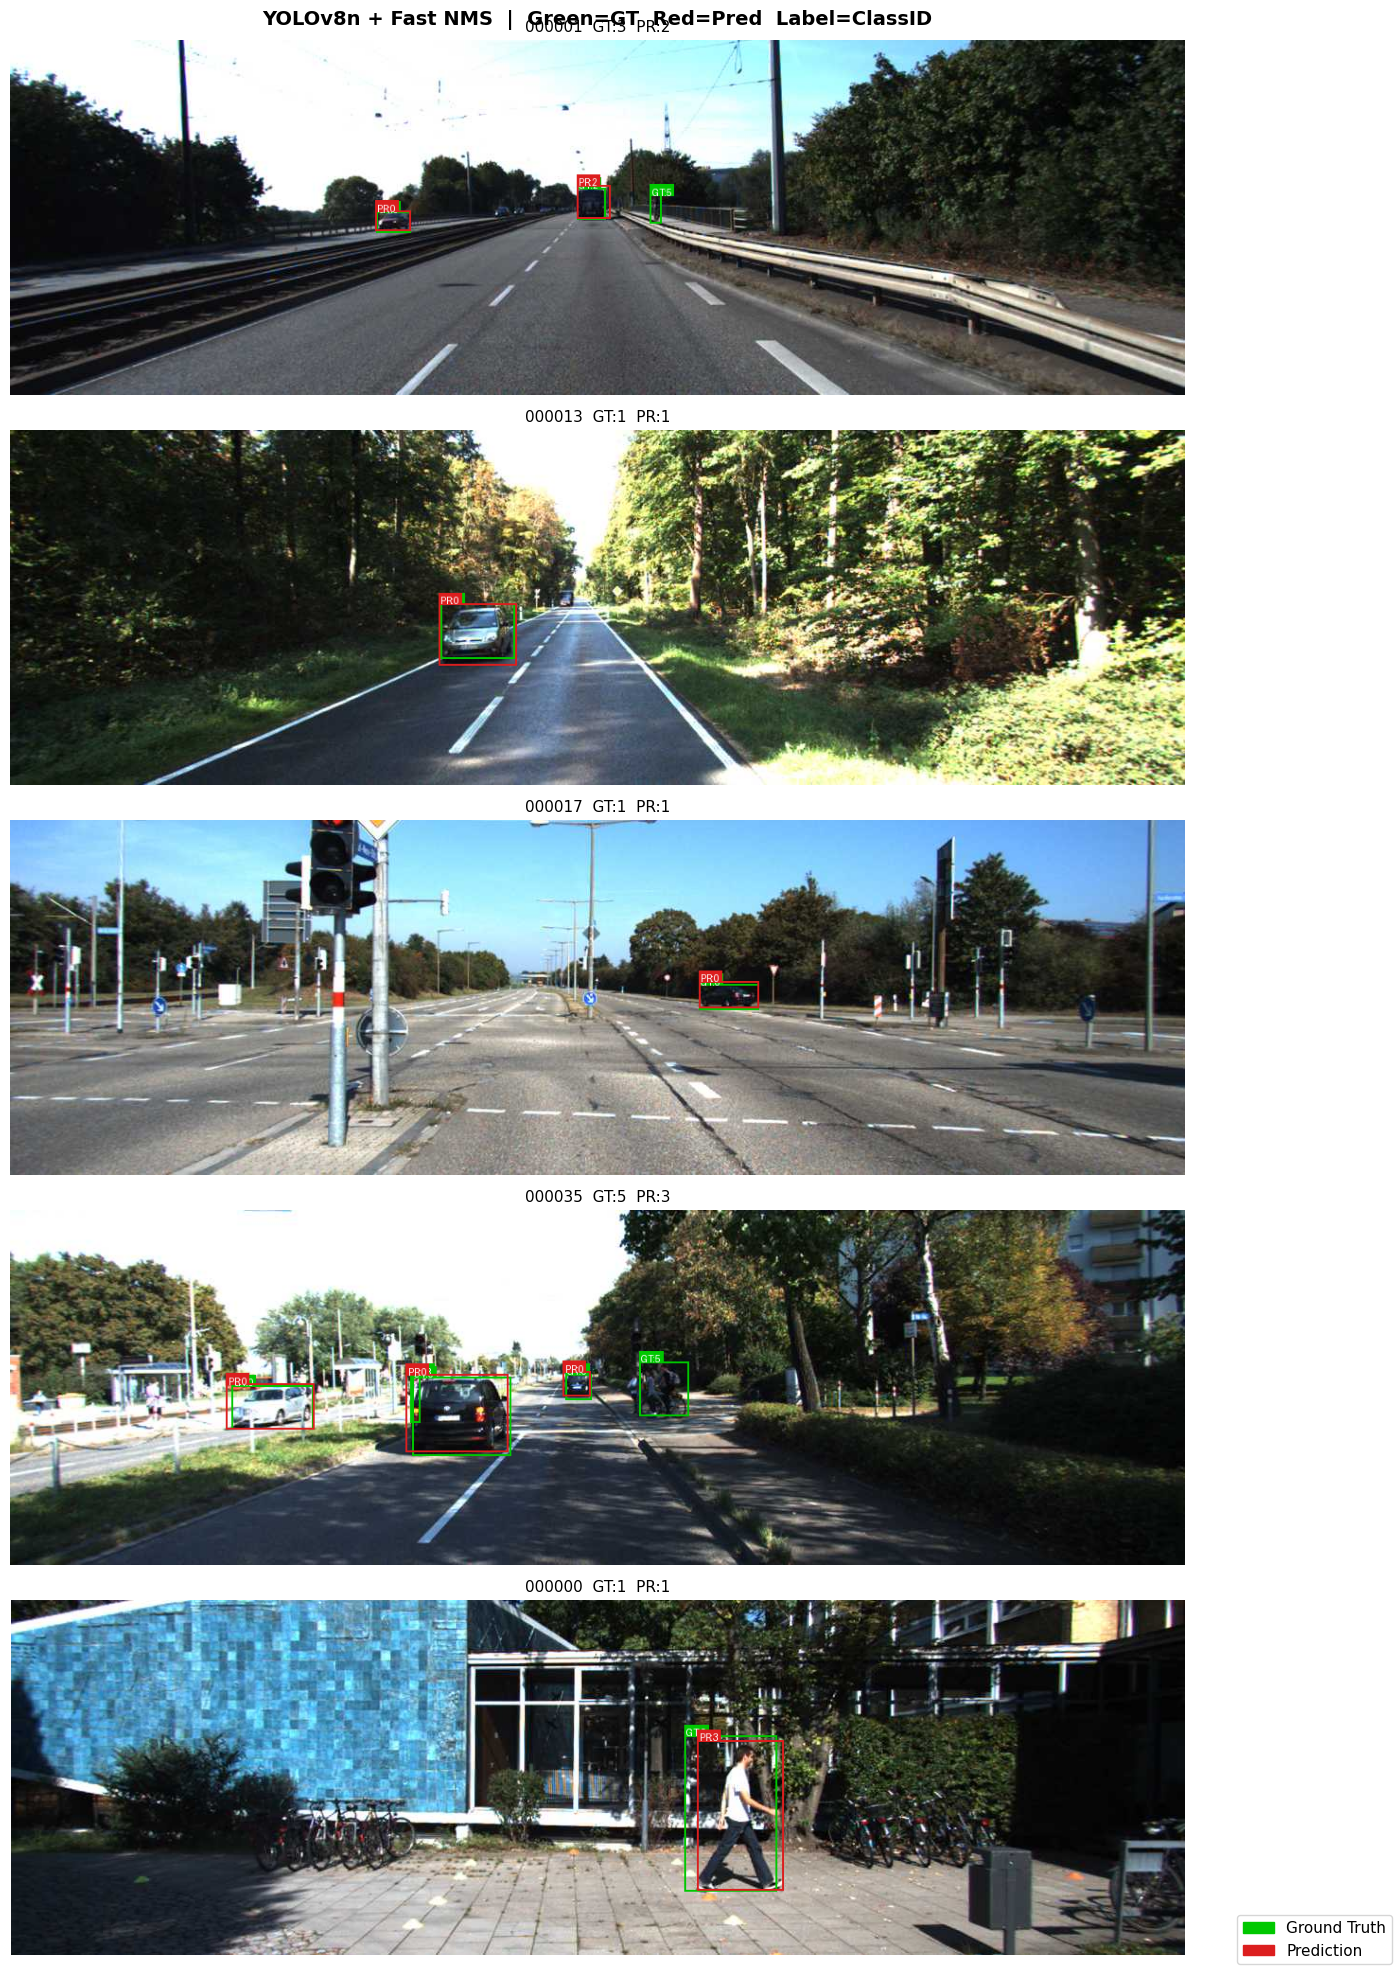

[fast_nms] restored original torchvision.ops.nms


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO

DEMO_IDS = ['000001', '000013', '000017', '000035', '000000']
IMG_DIR  = Path('datasets/kitti_dataset/images/val')
LBL_DIR  = Path('datasets/kitti_dataset/labels/val')

# KITTI class names
CLASS_NAMES = {
    0: 'Car', 1: 'Van', 2: 'Truck', 3: 'Pedestrian',
    4: 'Person_sitting', 5: 'Cyclist', 6: 'Tram', 7: 'Misc',
}

GT_COLOR   = (0, 200, 0)
PRED_COLOR = (220, 30, 30)

demo_model = YOLO(BEST_PT)
fast_nms.patch()   # use Fast NMS for demo


def yolo_to_xyxy(cx, cy, w, h, iw, ih):
    return [(cx - w/2)*iw, (cy - h/2)*ih, (cx + w/2)*iw, (cy + h/2)*ih]


def draw_boxes(img, gt_boxes, pred_boxes):
    out  = img.copy()
    draw = ImageDraw.Draw(out)
    try:
        font = ImageFont.truetype('arial.ttf', 13)
    except Exception:
        font = ImageFont.load_default()
    for boxes, color, prefix in [(gt_boxes, GT_COLOR, 'GT'), (pred_boxes, PRED_COLOR, 'PR')]:
        for cid, x1, y1, x2, y2 in boxes:
            label = f'{prefix}:{int(cid)}'
            draw.rectangle([x1, y1, x2, y2], outline=color, width=2)
            bb = draw.textbbox((x1, y1), label, font=font)
            tw, th = bb[2]-bb[0], bb[3]-bb[1]
            ty = y1-th-3 if y1-th-3 >= 0 else y1+2
            draw.rectangle([x1, ty, x1+tw+4, ty+th+4], fill=color)
            draw.text((x1+2, ty+2), label, fill=(255,255,255), font=font)
    return out


fig, axes = plt.subplots(len(DEMO_IDS), 1, figsize=(16, 4*len(DEMO_IDS)))
fig.suptitle('YOLOv8n + Fast NMS  |  Green=GT  Red=Pred  Label=ClassID',
             fontsize=14, fontweight='bold')

for ax, img_id in zip(axes, DEMO_IDS):
    img_path = IMG_DIR / f'{img_id}.png'
    lbl_path = LBL_DIR / f'{img_id}.txt'

    if not img_path.exists():
        ax.set_title(f'{img_id} not found'); ax.axis('off'); continue

    img = Image.open(img_path).convert('RGB')
    iw, ih = img.size

    # Ground truth
    gt_boxes = []
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            parts = line.split()
            if len(parts) == 5:
                cls, cx, cy, w, h = int(parts[0]), *map(float, parts[1:])
                gt_boxes.append([cls, *yolo_to_xyxy(cx, cy, w, h, iw, ih)])

    # Prediction
    res = demo_model.predict(str(img_path), verbose=False, device=0)[0]
    pred_boxes = []
    if res.boxes is not None:
        for box in res.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            pred_boxes.append([int(box.cls), x1, y1, x2, y2])

    vis = draw_boxes(img, gt_boxes, pred_boxes)
    ax.imshow(vis)
    ax.set_title(f'{img_id}  GT:{len(gt_boxes)}  PR:{len(pred_boxes)}', fontsize=11)
    ax.axis('off')

g_patch = mpatches.Patch(color=(0,200/255,0),         label='Ground Truth')
r_patch = mpatches.Patch(color=(220/255,30/255,30/255), label='Prediction')
fig.legend(handles=[g_patch, r_patch], loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

fast_nms.unpatch()
del demo_model

In [15]:
# Save demo figure to Drive
import shutil
DRIVE_OUT = '/content/drive/MyDrive/yolo_results/yolov8n_kitti'
Path(DRIVE_OUT).mkdir(parents=True, exist_ok=True)
fig.savefig(f'{DRIVE_OUT}/demo_fastnms.png', dpi=150, bbox_inches='tight')
print(f'Demo saved to Drive: {DRIVE_OUT}/demo_fastnms.png')

Demo saved to Drive: /content/drive/MyDrive/yolo_results/yolov8n_kitti/demo_fastnms.png


---
## 6. Video Inference

Runs YOLOv8n + Fast NMS on a video file and saves the annotated output.

> **Colab note**: Upload your video via the Files panel (left sidebar)  
> or download directly with `!gdown` / `!wget`.  
> `show=False` is set intentionally — Colab has no display window.

In [16]:
# 6-A: (Optional) Export to TensorRT for faster video inference
# Skip this cell if you only want PyTorch inference.
from pathlib import Path

TRT_ENGINE = Path(BEST_PT).parent / (Path(BEST_PT).stem + '.engine')

if not TRT_ENGINE.exists():
    from ultralytics import YOLO
    _m = YOLO(BEST_PT)
    _m.export(format='engine', half=True, device=0, nms=False)
    print(f'TRT engine exported: {TRT_ENGINE}')
else:
    print(f'TRT engine already exists: {TRT_ENGINE}')


Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/train-4/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 13, 8400) (23.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime-gpu', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 276ms
Prepared 4 packages in 4.04s
Installed 4 packages in 235ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 5.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 18...
ONNX: slimming with 

AttributeError: type object 'tensorrt_bindings.tensorrt.BuilderFlag' has no attribute 'FP16'

In [ ]:
# 6-B: Video inference + FPS measurement
# Can run independently of 6-A (auto-detects whether TRT engine exists).
import time
from pathlib import Path
from ultralytics import YOLO
import fast_nms

# ── Config ────────────────────────────────────────────────────────────
VIDEO_PATH   = 'road.mp4'           # Change to your video file path
CONF_THRESH  = 0.30
USE_FAST_NMS = True                 # Apply Fast NMS patch (PyTorch only)
# ──────────────────────────────────────────────────────────────────────

# Auto-detect TRT engine (works even if 6-A was skipped)
TRT_ENGINE = Path(BEST_PT).parent / (Path(BEST_PT).stem + '.engine')
USE_TRT    = TRT_ENGINE.exists()

model_path = str(TRT_ENGINE) if USE_TRT else BEST_PT
print(f'Model : {model_path}  ({"TensorRT" if USE_TRT else "PyTorch"})')
print(f'Video : {VIDEO_PATH}')

if USE_FAST_NMS and not USE_TRT:
    fast_nms.patch()   # TRT model handles NMS internally; no patch needed

vid_model = YOLO(model_path)

t0 = time.perf_counter()
vid_results = vid_model.predict(
    source=VIDEO_PATH,
    conf=CONF_THRESH,
    device=0,
    show=False,    # No display in Colab
    save=True,     # Save annotated video to runs/detect/predict/
    stream=True,   # Memory-efficient streaming mode
)

n_frames = 0
for _ in vid_results:
    n_frames += 1

elapsed = time.perf_counter() - t0
fps = n_frames / elapsed

if USE_FAST_NMS and not USE_TRT:
    fast_nms.unpatch()

print(f'\nVideo inference complete.')
print(f'  Model            : {"TensorRT (FP16)" if USE_TRT else "PyTorch"}')
print(f'  Fast NMS applied : {USE_FAST_NMS and not USE_TRT}')
print(f'  Frames processed : {n_frames}')
print(f'  Total time       : {elapsed:.1f} s')
print(f'  Average FPS      : {fps:.1f}')
print(f'  Annotated video saved to: runs/detect/predict/')

In [ ]:
# 6-C: Preview first frame of the annotated video inline
import cv2, glob
from IPython.display import display
from PIL import Image

saved_vids = sorted(
    glob.glob('runs/detect/predict*/*.avi') +
    glob.glob('runs/detect/predict*/*.mp4')
)
if saved_vids:
    vid_out = saved_vids[-1]
    cap = cv2.VideoCapture(vid_out)
    ok, frame = cap.read()
    cap.release()
    if ok:
        display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        print(f'First frame of: {vid_out}')
else:
    print('No saved video found. Check runs/detect/predict/.')


In [ ]:
# 6-D: Save annotated video to Drive
import shutil, glob
from pathlib import Path

DRIVE_VID_OUT = '/content/drive/MyDrive/yolo_results/yolov8n_kitti/video'
Path(DRIVE_VID_OUT).mkdir(parents=True, exist_ok=True)

saved_vids = sorted(
    glob.glob('runs/detect/predict*/*.avi') +
    glob.glob('runs/detect/predict*/*.mp4')
)
if saved_vids:
    for v in saved_vids:
        dest = shutil.copy(v, DRIVE_VID_OUT)
        print(f'Saved: {dest}')
else:
    print('No video to save.')


---
## 7. Results Summary

In [ ]:
# Final comparison table
import os

model_size_mb = os.path.getsize(BEST_PT) / 1e6

print('=' * 65)
print('  YOLOv8n + Fast NMS — KITTI Evaluation Summary')
print('=' * 65)
print(f'  Model          : YOLOv8n (fine-tuned on KITTI, {model_size_mb:.1f} MB)')
print(f'  mAP@0.5        : {map50:.4f}')
print(f'  mAP@0.5:0.95   : {map5095:.4f}')
print()

# 4-B results (real image, time.perf_counter)
std_ms  = results_bench['Standard NMS']['mean_ms']
fast_ms = results_bench['Fast NMS']['mean_ms']
print('  ── Real-image benchmark (perf_counter) ──────────────')
print(f"  {'Method':<20s} {'Latency (ms)':>14s} {'FPS':>10s} {'Speedup':>10s}")
print(f"  {'-'*20} {'-'*14} {'-'*10} {'-'*10}")
print(f"  {'Standard NMS':<20s} {std_ms:>14.2f} {1000/std_ms:>10.1f} {'1.00×':>10s}")
print(f"  {'Fast NMS':<20s} {fast_ms:>14.2f} {1000/fast_ms:>10.1f} {std_ms/fast_ms:>9.2f}×")
print()

# 4-D results (dummy frame, CUDA events)
c_std  = cuda_results['Standard NMS']
c_fast = cuda_results['Fast NMS']
print('  ── CUDA Event benchmark (dummy 640×640 frames) ──────')
print(f"  {'Method':<20s} {'Latency (ms)':>14s} {'FPS':>10s} {'Speedup':>10s}")
print(f"  {'-'*20} {'-'*14} {'-'*10} {'-'*10}")
print(f"  {'Standard NMS':<20s} {c_std['latency_ms']:>14.2f} {c_std['fps']:>10.1f} {'1.00×':>10s}")
print(f"  {'Fast NMS':<20s} {c_fast['latency_ms']:>14.2f} {c_fast['fps']:>10.1f} {c_fast['fps']/c_std['fps']:>9.2f}×")

req = '✓ meets ≥10 FPS requirement' if c_fast['fps'] >= 10 else '✗ below 10 FPS requirement'
print(f"\n  Fast NMS FPS: {c_fast['fps']:.1f}  →  {req}")
print('=' * 65)